In [ ]:

from pathlib import Path

DATA_PATH = Path(r"healthcare_patient_journey.csv")
TARGET_COLUMN = "readmitted_30d"
DROP_COLUMNS = ["patient_id"]
POSITIVE_LABEL = 1
TEST_SIZE = 0.25
RANDOM_STATE = 42


In [ ]:

import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


In [ ]:

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("Columns:")
for col in df.columns:
    print("-", col)

df.head()


Dataset shape: (3000, 15)
Columns:
- patient_id
- age
- gender
- chronic_condition
- admission_type
- department
- wait_time_min
- length_of_stay_days
- procedures_count
- medication_count
- complications
- discharge_status
- readmitted_30d
- total_cost_€
- satisfaction_score


,patient_id,age,gender,chronic_condition,admission_type,department,wait_time_min,length_of_stay_days,procedures_count,medication_count,complications,discharge_status,readmitted_30d,total_cost_€,satisfaction_score
0,1,69,male,0,scheduled,Neurology,41,2,0,3,1,referred,1,1440,2
1,2,38,male,0,emergency,Oncology,17,3,1,2,0,recovered,0,2060,3
2,3,81,male,0,scheduled,Neurology,40,2,3,2,0,recovered,0,2110,3
3,4,67,female,1,emergency,ER,7,4,5,9,0,recovered,0,4070,3
4,5,88,male,1,emergency,Cardiology,34,3,7,5,0,recovered,1,3800,3


In [ ]:

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 34, 49, 64, 150],
    labels=["18-34", "35-49", "50-64", "65+"],
    include_lowest=True
)

SENSITIVE_COLUMNS = ["gender", "age_group"]

display(df[SENSITIVE_COLUMNS + [TARGET_COLUMN]].head())
print(df[TARGET_COLUMN].value_counts().rename("count"))
print()
print("Target rate:")
display(df[TARGET_COLUMN].value_counts(normalize=True).rename("proportion").round(3))


,gender,age_group,readmitted_30d
0,male,65+,1
1,male,35-49,0
2,male,65+,0
3,female,65+,0
4,male,65+,1


readmitted_30d
0    2296
1     704
Name: count, dtype: int64

Target rate:


,proportion
readmitted_30d,
0,0.765
1,0.235


In [ ]:

X = df.drop(columns=[TARGET_COLUMN] + DROP_COLUMNS)
y = df[TARGET_COLUMN]

categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (2250, 14)
Test shape: (750, 14)


In [ ]:

overall_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Value": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred, zero_division=0)
    ]
})

display(overall_metrics.style.format({"Value": "{:.3f}"}))
print(classification_report(y_test, y_pred, zero_division=0))


,Metric,Value
0,Accuracy,0.651
1,Precision,0.375
2,Recall,0.733
3,F1 Score,0.496


              precision    recall  f1-score   support

           0       0.88      0.63      0.73       574
           1       0.38      0.73      0.50       176

    accuracy                           0.65       750
   macro avg       0.63      0.68      0.61       750
weighted avg       0.76      0.65      0.68       750



In [ ]:

def fairness_table(data, sensitive_col):
    rows = []

    for group_name, group_df in data.groupby(sensitive_col, observed=False):
        y_true_group = group_df["y_true"]
        y_pred_group = group_df["y_pred"]

        tn, fp, fn, tp = confusion_matrix(
            y_true_group, y_pred_group, labels=[0, 1]
        ).ravel()

        predicted_positive_rate = y_pred_group.mean()
        true_positive_rate = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else np.nan

        rows.append({
            "group": str(group_name),
            "n": len(group_df),
            "predicted_positive_rate": predicted_positive_rate,
            "true_positive_rate": true_positive_rate,
            "false_positive_rate": false_positive_rate,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp
        })

    result = pd.DataFrame(rows).sort_values("group").reset_index(drop=True)

    max_ppr = result["predicted_positive_rate"].max()
    result["disparate_impact"] = np.where(
        max_ppr > 0,
        result["predicted_positive_rate"] / max_ppr,
        np.nan
    )

    return result

def fairness_summary(result):
    return {
        "demographic_parity_gap": result["predicted_positive_rate"].max() - result["predicted_positive_rate"].min(),
        "equal_opportunity_gap": result["true_positive_rate"].max() - result["true_positive_rate"].min(),
        "equalized_odds_tpr_gap": result["true_positive_rate"].max() - result["true_positive_rate"].min(),
        "equalized_odds_fpr_gap": result["false_positive_rate"].max() - result["false_positive_rate"].min(),
        "lowest_disparate_impact": result["disparate_impact"].min()
    }


In [ ]:

results_df = X_test.copy()
results_df["y_true"] = y_test.values
results_df["y_pred"] = y_pred

results_df.head()


,age,gender,chronic_condition,admission_type,department,wait_time_min,length_of_stay_days,procedures_count,medication_count,complications,discharge_status,total_cost_€,satisfaction_score,age_group,y_true,y_pred
1278,71,male,0,emergency,Cardiology,5,4,3,1,0,recovered,2930,2,65+,0,0
1953,64,male,1,emergency,Polyclinic,30,5,3,3,1,referred,3540,1,50-64,1,1
2293,69,female,0,emergency,ER,5,3,0,4,0,recovered,1970,3,65+,0,0
1294,49,female,0,emergency,Neurology,18,3,1,5,0,recovered,2300,2,35-49,0,0
389,72,female,0,scheduled,Cardiology,33,2,3,2,0,recovered,2110,4,65+,0,0


In [ ]:

fairness_results = {}
fairness_summaries = []

for sensitive_col in SENSITIVE_COLUMNS:
    table = fairness_table(results_df, sensitive_col)
    summary = fairness_summary(table)

    fairness_results[sensitive_col] = table
    fairness_summaries.append({
        "Sensitive attribute": sensitive_col,
        **summary
    })

    print(f"Fairness table for: {sensitive_col}")
    display(table.style.format({
        "predicted_positive_rate": "{:.3f}",
        "true_positive_rate": "{:.3f}",
        "false_positive_rate": "{:.3f}",
        "disparate_impact": "{:.3f}"
    }))

fairness_summary_df = pd.DataFrame(fairness_summaries)
display(fairness_summary_df.style.format({
    "demographic_parity_gap": "{:.3f}",
    "equal_opportunity_gap": "{:.3f}",
    "equalized_odds_tpr_gap": "{:.3f}",
    "equalized_odds_fpr_gap": "{:.3f}",
    "lowest_disparate_impact": "{:.3f}"
}))


Fairness table for: gender


,group,n,predicted_positive_rate,true_positive_rate,false_positive_rate,tn,fp,fn,tp,disparate_impact
0,female,364,0.464,0.709,0.388,170,108,25,61,1.000
1,male,386,0.453,0.756,0.361,189,107,22,68,0.976


Fairness table for: age_group


,group,n,predicted_positive_rate,true_positive_rate,false_positive_rate,tn,fp,fn,tp,disparate_impact
0,18-34,176,0.449,0.718,0.372,86,51,11,28,0.956
1,35-49,164,0.470,0.714,0.385,75,47,12,30,1.000
2,50-64,142,0.451,0.727,0.367,69,40,9,24,0.960
3,65+,268,0.463,0.758,0.374,129,77,15,47,0.985


,Sensitive attribute,demographic_parity_gap,equal_opportunity_gap,equalized_odds_tpr_gap,equalized_odds_fpr_gap,lowest_disparate_impact
0,gender,0.011,0.046,0.046,0.027,0.976
1,age_group,0.021,0.044,0.044,0.018,0.956


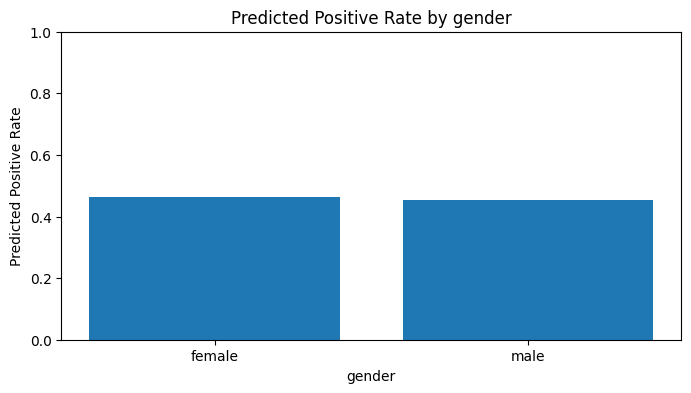

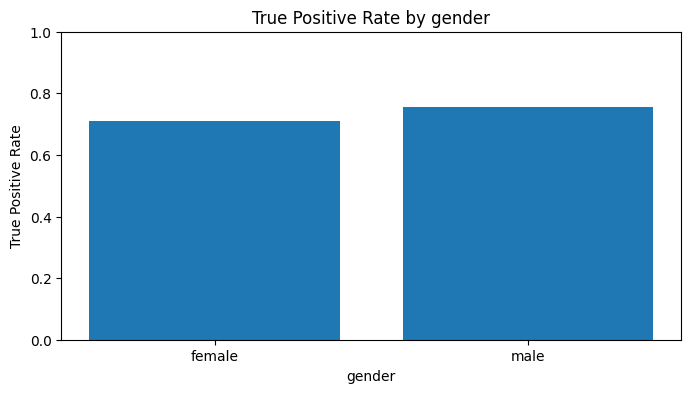

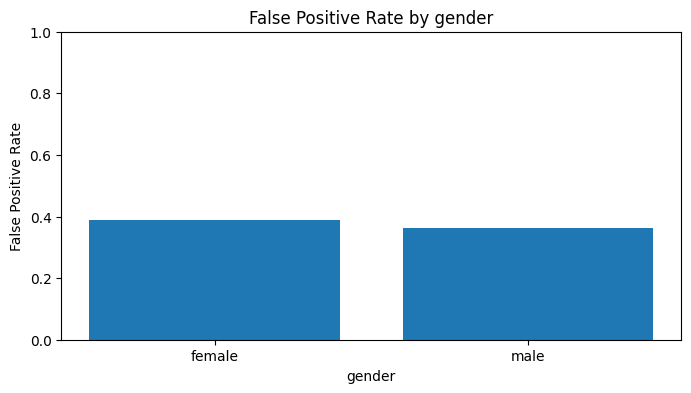

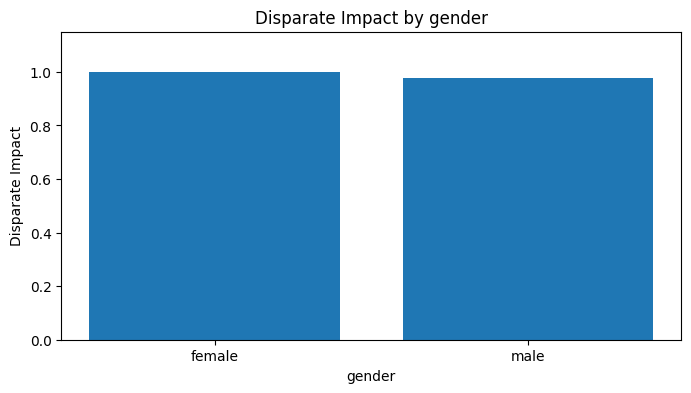

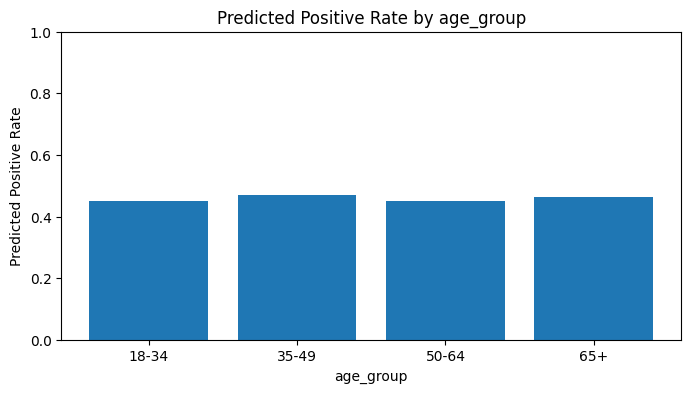

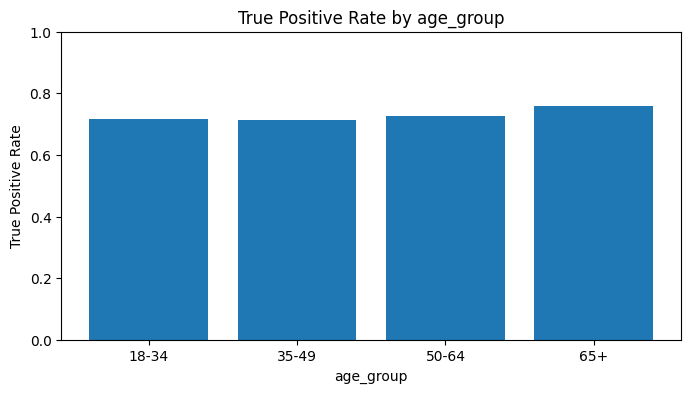

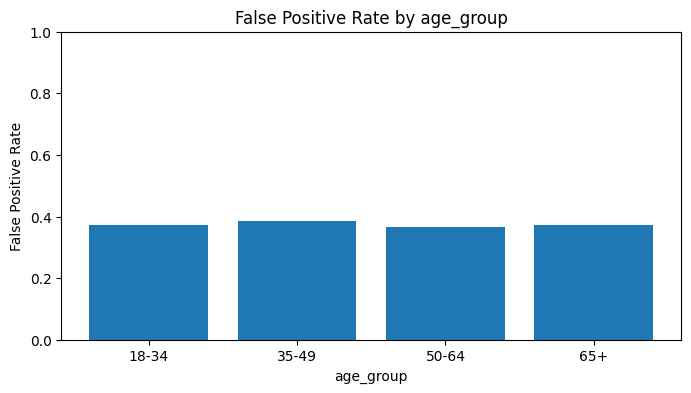

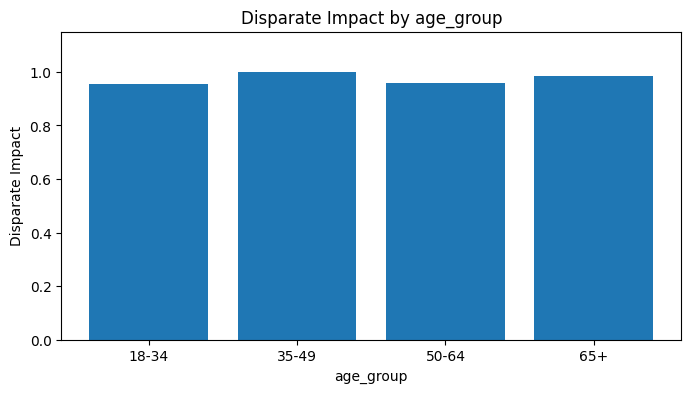

In [ ]:

metric_labels = {
    "predicted_positive_rate": "Predicted Positive Rate",
    "true_positive_rate": "True Positive Rate",
    "false_positive_rate": "False Positive Rate",
    "disparate_impact": "Disparate Impact"
}

for sensitive_col, table in fairness_results.items():
    for metric in metric_labels:
        plt.figure(figsize=(8, 4))
        plt.bar(table["group"], table[metric])
        plt.title(f"{metric_labels[metric]} by {sensitive_col}")
        plt.xlabel(sensitive_col)
        plt.ylabel(metric_labels[metric])
        plt.xticks(rotation=0)
        plt.ylim(0, max(1.0, table[metric].max() * 1.15 if table[metric].notna().any() else 1.0))
        plt.show()


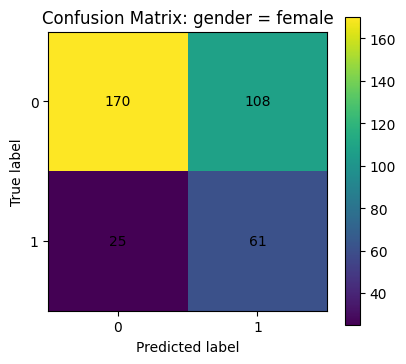

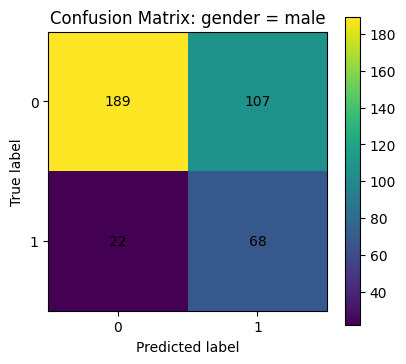

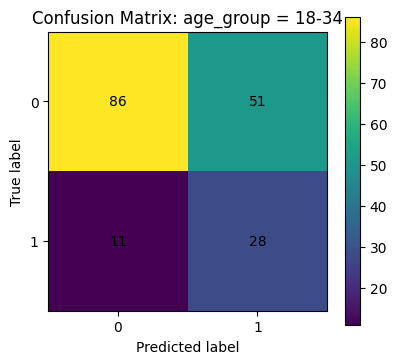

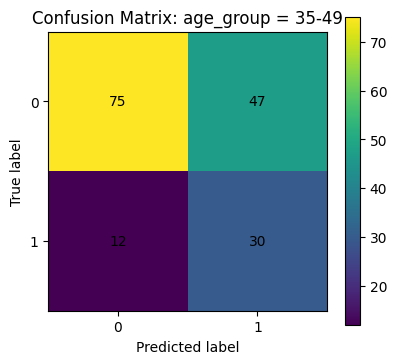

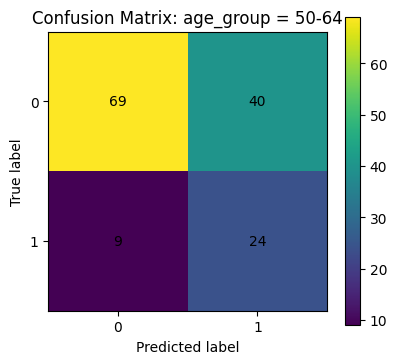

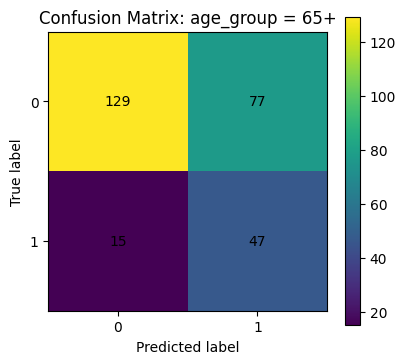

In [ ]:

for sensitive_col, table in fairness_results.items():
    for _, row in table.iterrows():
        matrix = np.array([[row["tn"], row["fp"]], [row["fn"], row["tp"]]])

        plt.figure(figsize=(4.5, 4))
        plt.imshow(matrix, interpolation="nearest")
        plt.title(f"Confusion Matrix: {sensitive_col} = {row['group']}")
        plt.xlabel("Predicted label")
        plt.ylabel("True label")
        plt.xticks([0, 1], [0, 1])
        plt.yticks([0, 1], [0, 1])

        for i in range(2):
            for j in range(2):
                plt.text(j, i, int(matrix[i, j]), ha="center", va="center")

        plt.colorbar()
        plt.show()


In [ ]:

def summarize_bias(fairness_results):
    notes = []

    for sensitive_col, table in fairness_results.items():
        summary = fairness_summary(table)

        highest_fpr_group = table.loc[table["false_positive_rate"].idxmax()]
        lowest_tpr_group = table.loc[table["true_positive_rate"].idxmin()]
        low_di = table[table["disparate_impact"] < 0.80]

        notes.append(f"### Sensitive attribute: {sensitive_col}")
        notes.append(
            f"- **Demographic parity gap:** {summary['demographic_parity_gap']:.3f}. "
            "This shows how different the positive prediction rates are across groups."
        )
        notes.append(
            f"- **Equal opportunity gap:** {summary['equal_opportunity_gap']:.3f}. "
            "This shows how different the true positive rates are across groups."
        )
        notes.append(
            f"- **Equalized odds signal (FPR gap):** {summary['equalized_odds_fpr_gap']:.3f}. "
            "This shows whether some groups receive false positives more often."
        )
        notes.append(
            f"- **Highest false positive rate:** {highest_fpr_group['group']} "
            f"({highest_fpr_group['false_positive_rate']:.3f})."
        )
        notes.append(
            f"- **Lowest true positive rate:** {lowest_tpr_group['group']} "
            f"({lowest_tpr_group['true_positive_rate']:.3f})."
        )

        if len(low_di) > 0:
            impacted_groups = ", ".join(low_di["group"].astype(str).tolist())
            notes.append(
                f"- **Disparate impact warning:** the following groups fall below the common 0.80 threshold: {impacted_groups}."
            )
        else:
            notes.append("- **Disparate impact check:** no group fell below the 0.80 threshold in this run.")

        notes.append(
            "- **Interpretation:** a lower true positive rate means the model may miss patients in that group who actually are at risk. "
            "A higher false positive rate means that group may receive extra alerts or follow-up that other groups do not."
        )
        notes.append("")

    return "\n".join(notes)

display(Markdown(summarize_bias(fairness_results)))


### Sensitive attribute: gender
- **Demographic parity gap:** 0.011. This shows how different the positive prediction rates are across groups.
- **Equal opportunity gap:** 0.046. This shows how different the true positive rates are across groups.
- **Equalized odds signal (FPR gap):** 0.027. This shows whether some groups receive false positives more often.
- **Highest false positive rate:** female (0.388).
- **Lowest true positive rate:** female (0.709).
- **Disparate impact check:** no group fell below the 0.80 threshold in this run.
- **Interpretation:** a lower true positive rate means the model may miss patients in that group who actually are at risk. A higher false positive rate means that group may receive extra alerts or follow-up that other groups do not.

### Sensitive attribute: age_group
- **Demographic parity gap:** 0.021. This shows how different the positive prediction rates are across groups.
- **Equal opportunity gap:** 0.044. This shows how different the true positive rates are across groups.
- **Equalized odds signal (FPR gap):** 0.018. This shows whether some groups receive false positives more often.
- **Highest false positive rate:** 35-49 (0.385).
- **Lowest true positive rate:** 35-49 (0.714).
- **Disparate impact check:** no group fell below the 0.80 threshold in this run.
- **Interpretation:** a lower true positive rate means the model may miss patients in that group who actually are at risk. A higher false positive rate means that group may receive extra alerts or follow-up that other groups do not.
